# ♟️ Össze játszma vizualizációja

Ez a notebook a `02_analysis.py` által generált `stats.json` és a `03_stockfish_analysis.py` által generált `stockfish_analysis.json` fájlokat jeleníti meg interaktív Plotly grafikonokkal.

**Futtatás előtt:** Győződj meg róla, hogy a pipeline 1-3. lépései lefutottak.

---

In [1]:
import subprocess, sys, os

root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_dir not in sys.path:
    sys.path.append(root_dir)
import config

if not os.path.exists(config.STATS_JSON):
    print("stats.json nem található – pipeline futtatása...")
    result = subprocess.run(
        [sys.executable, os.path.join(root_dir, "src", "run_pipeline.py"), "--pgn", config.PGN_FILE],
        cwd=root_dir,
    )
    if result.returncode != 0:
        raise RuntimeError("Pipeline futtatása sikertelen! Ellenőrizd a PGN fájlt és a config.py-t.")
    print("✅ Pipeline kész.")
else:
    print(f"✅ Adatok már megvannak: {config.STATS_JSON}")

✅ Adatok már megvannak: D:\Workspace\chess-pgn-analysis\output\analysis\stats.json


## 1. Előkészítés és adatok betöltése

In [2]:
import sys, os
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_dir not in sys.path:
    sys.path.append(root_dir)
import config

import json
import math
import numpy as np
import pandas as pd

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

if not os.path.exists(config.STATS_JSON):
    raise FileNotFoundError(
        f"Nem található a statisztika fájl: {config.STATS_JSON}. "
        "Futtasd a pipeline 2. lépését: python src/run_pipeline.py --pgn sakkpartik.pgn"
    )
with open(config.STATS_JSON, encoding='utf-8') as f:
    stats = json.load(f)
sf_data = {}
if os.path.exists(config.STOCKFISH_JSON):
    with open(config.STOCKFISH_JSON, encoding='utf-8') as f:
        sf_data = json.load(f)


TOTAL = stats.get('total_games', 0)
print(f'   Stockfish elemzés: {"igen" if sf_data.get("evaluations") else "nem elérhető"}')

THEME = config.PLOT_THEME
print(f'✅ Adatok betöltve. Összes játszma: {TOTAL:,}')

   Stockfish elemzés: nem elérhető
✅ Adatok betöltve. Összes játszma: 1,377


## 2. Sakkjátszmák hossza

### 2.1 Az én játszmáim hossza (PLY-ban, azaz féllépésben)

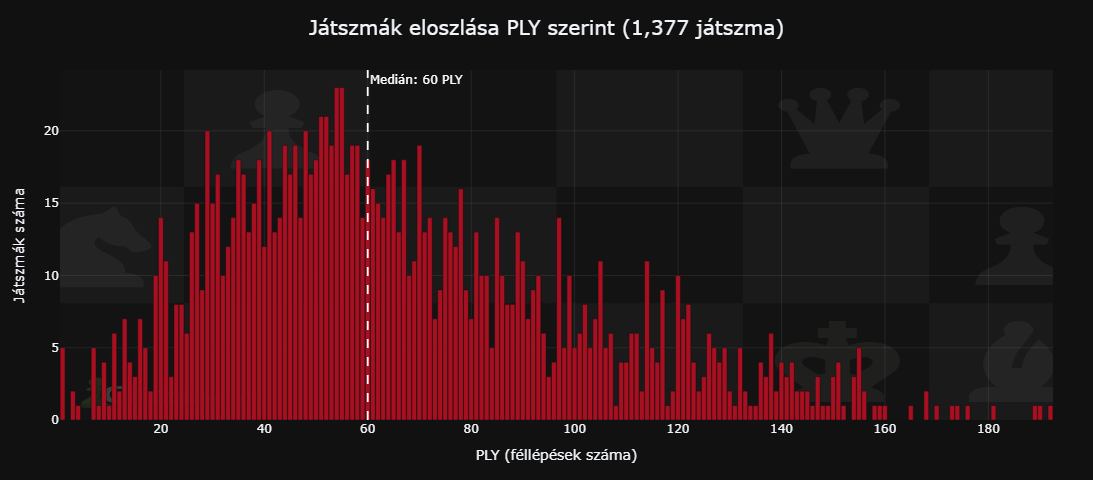

In [3]:
import base64, io
from PIL import Image

# Háttérkép base64-be
_img = Image.open(os.path.join(root_dir, 'notebooks', 'notebooks_src', 'bg1.png')).convert('RGB')
_buf = io.BytesIO()
_img.save(_buf, format='PNG')
_bg = 'data:image/png;base64,' + base64.b64encode(_buf.getvalue()).decode()

dist  = stats.get('move_count_dist', [])
mv_st = stats.get('move_stats', {})

if not dist:
    print('Nincs adat.')
else:
    df = pd.DataFrame(dist).sort_values('num_moves')

    fig = go.Figure(go.Bar(
        x=df['num_moves'],
        y=df['count'],
        marker_color='#A81022',
        hovertemplate='%{x} PLY → %{y:,} játszma<extra></extra>',
    ))

    median = mv_st.get('median_moves')
    if median is not None:
        fig.add_vline(
            x=float(median),
            line=dict(color='#ffffff', dash='dash', width=1.8),
            annotation_text=f'Medián: {float(median):.0f} PLY',
            annotation_font=dict(size=12, color='#ffffff'),
            annotation_position='top right',
        )

    fig.add_layout_image(dict(
        source=_bg,
        xref='paper', yref='paper',
        x=0, y=1, sizex=1, sizey=1,
        sizing='stretch',
        opacity=0.18,
        layer='below',
    ))

    fig.update_layout(
        title=dict(
            text=f'Játszmák eloszlása PLY szerint ({TOTAL:,} játszma)',
            font=dict(size=20),
            x=0.5,
            xanchor='center',
        ),
        xaxis=dict(
            title='PLY (féllépések száma)',
            gridcolor='rgba(255,255,255,0.08)',
            zeroline=False,
        ),
        yaxis=dict(
            title='Játszmák száma',
            gridcolor='rgba(255,255,255,0.08)',
            zeroline=False,
        ),
        template=THEME,
        plot_bgcolor='rgba(0,0,0,0)',
        height=480,
        bargap=0.06,
        showlegend=False,
        margin=dict(l=60, r=40, t=70, b=60),
    )

    fig.show()
    # fig.write_html(os.path.join(config.PLOTS_DIR, 'ply_distribution.html'))


## 2.2 Score sheet - avagy milyen hosszú játszmára lett kitalálva?

Az esetek __ %-ában nem kellett volna új játszmalapot kérnem, ha OTB (over the board) játszmák lettek volna az online játszott partijaim. :)

<Official Chess.com Score Sheet.pdf fájl megjelenítése notebooks/notebooks_src-ből>